<a href="https://colab.research.google.com/github/sandrokhizanishvili/AML_GNN_GMA/blob/main/baseline_model_enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GINe with Enhanced Features for Anti-Money Laundering Detection

**Course:** Graph Mining and Applications, Sapienza University of Rome

---

## What This Notebook Does

This notebook trains and evaluates a **Graph Isomorphism Network with Edge Features (GINe)** for detecting money laundering in financial transaction networks using the **GFP feature set** from `Data_preparation_gfp.ipynb`. The task is framed as an **edge classification** problem: given a transaction between two bank accounts, the model must decide whether it is legitimate (label 0) or part of a laundering scheme (label 1).

The implementation follows the methodology from:

> Altman et al. (2023). *Realistic Synthetic Financial Transactions for Anti-Money Laundering Models.* arXiv:2306.16424

We use the **LI-Small** dataset from the IBM AML benchmark, which represents a realistic low-illicit-ratio scenario.

---

## The Dataset at a Glance

The financial network is represented as a directed graph where:
- Each **node** is a bank account
- Each **edge** is a transaction between two accounts
- Each edge carries a binary label: 0 (legitimate) or 1 (laundering)

| Property | Value |
|----------|-------|
| Bank accounts (nodes) | 712,684 |
| Transactions (edges) | 6,924,049 |
| Node feature dimensions | 6 |
| Edge feature dimensions | 77 |
| Laundering rate | ~0.04% (severe class imbalance) |
| Data split | 60% train / 20% val / 20% test (temporal) |

The extreme class imbalance (roughly 2,290 legitimate transactions for every 1 laundering transaction) is the central challenge of this task.  https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/data

---

## Model Summary

We implement **GINe with edge readout**, which is the GIN baseline from the paper. The key design choices are:

| Design choice | What it is | Why we use it |
|---------------|------------|---------------|
| GINEConv | Graph Isomorphism Network with edge features | Most expressive standard message passing; edge features modulate neighbour messages |
| 2 GNN layers | Two rounds of message passing | Each layer extends the receptive field by one hop; 2 layers = 2-hop neighbourhood |
| Edge readout decoder | concat(h[src], h[dst], e_seed) | Combines account context with the specific transaction features for classification |
| LayerNorm | Normalisation per node | BatchNorm fails with severe class imbalance because majority class dominates batch statistics |
| pos_weight = 50 | Upweights laundering loss | Compensates for 2,290:1 imbalance without oversampling |
| Neighbourhood sampling [100, 100] | 100 one-hop + 100 two-hop neighbours | Matches paper exactly; avoids loading the full graph into GPU memory |

---

## Notebook Structure

1. Installation
2. Imports and reproducibility setup
3. Loading the graph data
4. Hyperparameters
5. Model architecture (GINe)
6. Data loader
7. Training and evaluation functions
8. Training the model
9. Threshold optimisation
10. Results and comparison with the paper

## 1. Installation

This cell installs the correct versions of PyTorch and PyTorch Geometric for Colab.


If the libraries are already installed correctly, you can skip this cell.

In [1]:
print("🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...")

# 1. Uninstall the current mismatching versions
# We remove the one you just spent 15 mins compiling, because re-installing
# the CORRECT version via wheels will take only 30 seconds.
# os.system("pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib")
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib

# 2. Install PyTorch 2.8.0 (with CUDA 12.6 support)
# We specify the version explicitly to match the PyG documentation you found.
print("⬇️ Installing PyTorch 2.8.0...")
# os.system("pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126")
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# 3. Install Graph Libraries for PyTorch 2.8
# This link matches the table in your screenshot: torch-2.8.0 + cu126
print("⬇️ Installing Graph Libraries (Wheels)...")
# os.system("pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html")
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

print("="*40)
print("✅ SETUP COMPLETE.")
print("⚠️ YOU MUST RESTART THE RUNTIME NOW (Runtime -> Restart Session)")
print("="*40)




import torch

try:
    import torch_sparse
    sparse_status = "✅ Installed"
    sparse_version = torch_sparse.__version__
except ImportError:
    sparse_status = "❌ Not Found"
    sparse_version = "N/A"

print(f"PyTorch Version:      {torch.__version__}")
print(f"CUDA Available:       {torch.cuda.is_available()}")
print(f"Torch Sparse Status:  {sparse_status} ({sparse_version})")

if torch.cuda.is_available() and sparse_status == "✅ Installed":
    print("\nSUCCESS! You are ready to run the training loop.")
else:
    print("\n⚠️ Something is still missing. Did you Restart the Runtime?")



!pip install torch_geometric

🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
⬇️ Installing PyTorch 2.8.0...
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 189.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 211.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 221.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 85.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 113.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━

## 2. Imports and Reproducibility

We import all required libraries and fix all random seeds so that results are reproducible across runs.

The main libraries used are:
- **PyTorch** for model definition and training
- **PyTorch Geometric (PyG)** for graph data structures and GNN layers
- **scikit-learn** for evaluation metrics
- **tqdm** for progress bars during training

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import math
import random
import warnings
from google.colab import drive
warnings.filterwarnings('ignore')

# ── Numerical ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, average_precision_score, matthews_corrcoef, auc
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── PyTorch Geometric ─────────────────────────────────────────────────────────
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import GINEConv, PNAConv
from torch_geometric.utils import degree
# ── RWPE ──────────────────────────────────────────────────────────────────────
from torch_geometric.transforms import AddRandomWalkPE  # NEW: random walk positional encoding

# ── Progress bar ──────────────────────────────────────────────────────────────
from tqdm import tqdm

print(f'PyTorch          : {torch.__version__}')
print(f'PyTorch Geometric: {torch_geometric.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device           : {device}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch          : 2.8.0+cu126
PyTorch Geometric: 2.7.0
Device           : cuda


## 3. Loading the Graph Data

The graph was built in `Data_preparation_gfp.ipynb` and saved as three PyG `Data` objects
using the **GFP feature set** (77 edge features, 6 node features). We load them here.

### Why Three Separate Graphs?

We use a **cumulative snapshot** design that follows the paper's protocol:

- `train_graph` contains only the training period edges. All of them are labelled and used for training.
- `val_graph` contains training + validation period edges. Only the new validation edges are evaluated; the training edges provide neighbourhood context for message passing.
- `test_graph` contains all edges from all periods. Only the test period edges are evaluated.

This design is important because financial transactions exist in a temporal context. A suspicious transaction in the test set should be evaluated using knowledge of the account's full history, not just the test period. By including all prior edges in each snapshot, we give the GNN access to that historical context during message passing.

### Data Split (Temporal)

The split is done chronologically to prevent data leakage:
- **Train:** first 60% of time period
- **Validation:** next 20%
- **Test:** final 20%

In [3]:
# Mount Google Drive where the graph files and model checkpoints are stored

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/GMA_GNN_AML')

Mounted at /content/drive


In [3]:
# DATA_DIR = 'Data'
DATA_DIR = '/kaggle/input/datasets/sandrokhizanishvili/gnn-aml-gfp'

# weights_only=False is needed because PyG Data objects contain custom Python classes.
# PyTorch 2.6+ changed the default to weights_only=True for security,
# but our files contain PyG-specific types that require full unpickling.
train_graph = torch.load(os.path.join(DATA_DIR, 'train_graph_gfp.pt'), weights_only=False)
val_graph   = torch.load(os.path.join(DATA_DIR, 'val_graph_gfp.pt'),   weights_only=False)
test_graph  = torch.load(os.path.join(DATA_DIR, 'test_graph_gfp.pt'),  weights_only=False)



# ── RWPE injection ────────────────────────────────────────────────────────────
# Compute Random Walk Positional Encoding per snapshot.
# Each snapshot uses only its own edges (no leakage):
#   train_graph  →  edges from train period only
#   val_graph    →  train + val edges
#   test_graph   →  all edges
#
# RWPE(node_i, k) = probability that a random walk starting at node i
#                   returns to node i in exactly k steps.
# walk_length=4 captures cycles up to length 4 (scatter-gather patterns).
# Each node gets 4 extra dimensions appended to data.x.
# ─────────────────────────────────────────────────────────────────────────────
RWPE_WALK_LENGTH = 4   # NEW: 4 dimensions added to every node feature vector

def add_rwpe(graph, walk_length=RWPE_WALK_LENGTH):
    """
    Apply AddRandomWalkPE to a single graph snapshot and concatenate
    the resulting PE into graph.x.

    Parameters
    ----------
    graph       : PyG Data object (snapshot-specific edge_index used internally)
    walk_length : number of walk steps k — each becomes one PE dimension

    Returns
    -------
    graph with graph.x shape [N, original_node_dim + walk_length]
    """
    transform = AddRandomWalkPE(walk_length=walk_length, attr_name='rwpe')
    graph = transform(graph)                              # adds graph.rwpe [N, walk_length]
    graph.x = torch.cat([graph.x, graph.rwpe], dim=-1)  # concat into node features
    del graph.rwpe                                        # free memory, no longer needed
    return graph

print('Computing RWPE per snapshot (uses only each snapshot\'s own edges)...')
train_graph = add_rwpe(train_graph)
print(f'  train_graph: node feature dim {train_graph.x.shape[1]}')
val_graph   = add_rwpe(val_graph)
print(f'  val_graph:   node feature dim {val_graph.x.shape[1]}')
test_graph  = add_rwpe(test_graph)
print(f'  test_graph:  node feature dim {test_graph.x.shape[1]}')
print('RWPE done.')

def describe_graph(g, name):
    """
    Print a summary of one graph snapshot.

    Shows the number of nodes, total edges, how many edges are
    evaluated in this split, and the laundering rate among them.

    Parameters
    ----------
    g    : PyG Data object
    name : display name for printing
    """
    labels = g.y[g.eval_mask]
    n_pos  = (labels == 1).sum().item()
    n_eval = g.eval_mask.sum().item()
    print(f'{name}:')
    print(f'  Nodes          : {g.num_nodes:,}')
    print(f'  Edges (total)  : {g.edge_index.shape[1]:,}')
    print(f'  Eval edges     : {n_eval:,}')
    print(f'  Laundering     : {n_pos:,}  ({100*n_pos/n_eval:.4f}%)')
    print(f'  Node feat dim  : {g.x.shape[1]}')
    print(f'  Edge feat dim  : {g.edge_attr.shape[1]}')
    print()


describe_graph(train_graph, 'train_graph')
describe_graph(val_graph,   'val_graph')
describe_graph(test_graph,  'test_graph')

# Sanity check: verify that no label is -1 in any eval set.
# Labels should only be 0 (legitimate) or 1 (laundering).
# A -1 value would mean an unlabelled edge leaked into the eval mask.
for g, name in [(train_graph, 'train'), (val_graph, 'val'), (test_graph, 'test')]:
    labels = g.y[g.eval_mask]
    assert (labels == -1).sum() == 0, f'{name}: -1 labels found in eval set!'
    assert labels.unique().tolist() == [0, 1] or set(labels.unique().tolist()) <= {0, 1}
print('Label sanity check passed -- no -1 values in eval masks.')

train_graph:
  Nodes          : 712,684
  Edges (total)  : 4,154,429
  Eval edges     : 4,154,429
  Laundering     : 1,813  (0.0436%)
  Node feat dim  : 5
  Edge feat dim  : 77

val_graph:
  Nodes          : 712,684
  Edges (total)  : 5,539,239
  Eval edges     : 1,384,810
  Laundering     : 827  (0.0597%)
  Node feat dim  : 5
  Edge feat dim  : 77

test_graph:
  Nodes          : 712,684
  Edges (total)  : 6,924,049
  Eval edges     : 1,384,810
  Laundering     : 925  (0.0668%)
  Node feat dim  : 5
  Edge feat dim  : 77

Label sanity check passed -- no -1 values in eval masks.


## 4. Hyperparameters

All training and model hyperparameters are defined here in one place for easy tuning.

### Alignment with the Paper

The following settings match the paper exactly (Appendix E, Table 11, Table 12):
- `HIDDEN_DIM = 64` -- hidden embedding size
- `NUM_LAYERS = 2` -- number of GNN message passing layers
- `NUM_NEIGHBORS = [100, 100]` -- 100 one-hop and 100 two-hop neighbours sampled per seed edge

### Class Imbalance Handling

With a 2,290:1 ratio of legitimate to laundering transactions, the model would simply predict everything as legitimate without correction. We use `pos_weight = 50` in the Binary Cross-Entropy loss, which means every laundering transaction contributes 50x more to the loss than a legitimate one. This forces the model to pay attention to the rare class.

The paper used `pos_weight` in the range (6, 8). We use 50 because we train on the real distribution (no oversampling), which requires a stronger correction.

In [4]:
# ── Dimensions (inferred from data) ──────────────────────────────────────────
# NODE_DIM is read after RWPE concatenation so it picks up the new dimension
# automatically: 6 (original) + 4 (RWPE walk_length) = 10
NODE_DIM = train_graph.x.shape[1]          # NEW: 10 (was 6, +4 RWPE dims)
EDGE_DIM = train_graph.edge_attr.shape[1]  # 77 — unchanged

# ── Model ─────────────────────────────────────────────────────────────────────
HIDDEN_DIM = 128   # NEW: increased from 64 → 128 to better map 77-dim edge attributes
NUM_LAYERS = 2     # matches the paper: 2 GNN layers
DROPOUT    = 0.3

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS       = 10
LR           = 1e-3
WEIGHT_DECAY = 1e-5

# ── Neighbourhood sampling ────────────────────────────────────────────────────
# num_neighbors[0] = neighbours to sample at 2-hop (outermost)
# num_neighbors[1] = neighbours to sample at 1-hop (closest to seed)
# Must have one value per GNN layer
NUM_NEIGHBORS = [100, 100]
BATCH_SIZE    = 16384 # 4096

# ── Class imbalance ───────────────────────────────────────────────────────────
n_neg_train = (train_graph.y[train_graph.eval_mask] == 0).sum().item()
n_pos_train = (train_graph.y[train_graph.eval_mask] == 1).sum().item()
print(f'Train imbalance  : {n_neg_train/n_pos_train:.0f}:1  '
      f'({n_pos_train:,} pos / {n_neg_train:,} neg)')

POS_WEIGHT = torch.tensor([8.0], device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)

print(f'\nConfig:')
print(f'  NODE_DIM={NODE_DIM}, EDGE_DIM={EDGE_DIM}')
print(f'  HIDDEN_DIM={HIDDEN_DIM}, NUM_LAYERS={NUM_LAYERS}, DROPOUT={DROPOUT}')
print(f'  EPOCHS={EPOCHS}, LR={LR}, BATCH_SIZE={BATCH_SIZE}')
print(f'  NUM_NEIGHBORS={NUM_NEIGHBORS}')
print(f'  POS_WEIGHT={POS_WEIGHT.item()}')

Train imbalance  : 2290:1  (1,813 pos / 4,152,616 neg)

Config:
  NODE_DIM=5, EDGE_DIM=77
  HIDDEN_DIM=64, NUM_LAYERS=2, DROPOUT=0.3
  EPOCHS=10, LR=0.001, BATCH_SIZE=16384
  NUM_NEIGHBORS=[100, 100]
  POS_WEIGHT=8.0


## 5. Model Architecture

### The Core Problem: Classifying Edges, Not Nodes

Standard GNNs produce **node embeddings** through message passing. But our task is to classify **edges** (transactions). This requires a two-step pattern:

1. **Encode** -- run message passing over the neighbourhood graph to build informative node embeddings
2. **Decode** -- for each transaction we want to classify, look up the sender and receiver embeddings and combine them with the transaction's own features to produce a classification

This encode-decode separation is also required by how PyG's `LinkNeighborLoader` works. It keeps two sets of edges in each batch:
- `batch.edge_index` -- context edges used only for message passing (no labels)
- `batch.edge_label_index` -- seed edges that we actually want to classify (have labels)



### Why LayerNorm Instead of BatchNorm

BatchNorm normalises across the entire batch. With ~200,000 context edges per batch but only ~1 laundering edge on average, the batch mean and variance are completely dominated by legitimate transactions. LayerNorm normalises each node independently across its 64 features, so laundering nodes keep their distinctive activation patterns regardless of the class distribution in the batch.

### GINe Architecture Overview

The full forward pass for one transaction A to B looks like this:

```
INPUT
  x [N, 6]         -- raw node features for all accounts
  edge_attr [E, 77] -- raw edge features for context transactions
  edge_label_attr [n_seeds, 77] -- raw features of the seed transactions

ENCODE (runs on the context graph to build node embeddings)
  node_proj:  x [N,6]          --> h0 [N, 64]
  edge_proj:  edge_attr [E,77] --> e  [E, 64]

  Layer 1 (GINEConv):
    For each account v:
      msg = SUM over neighbours u: ReLU(h0[u] + e[u->v])
      h1[v] = MLP(h0[v] + msg)  -- 64->128->64
    Then: LayerNorm -> ReLU -> Dropout

  Layer 2 (GINEConv): same as layer 1, using h1
    Produces h2 [N, 64]

DECODE (classifies the seed transactions)
  For transaction A -> B:
    e_seed = edge_proj(edge_label_attr) --> [n_seeds, 64]
    edge_emb = concat(h2[A], h2[B], e_seed) --> [n_seeds, 192]
    logit = MLP(edge_emb)  -- 192->64->1
    P(laundering) = sigmoid(logit)
```

The three components in the decoder each carry different information:
- `h2[A]` -- what kind of sender account A is (its full 2-hop neighbourhood context)
- `h2[B]` -- what kind of receiver account B is
- `e_seed` -- the specific features of this particular transaction (FX-corrected amount, currency mismatch, payment format, timing, and GFP features: scatter-gather histograms, temporal cycle patterns, and vertex statistics)

Without `e_seed`, the model would assign the same score to every transaction between the same pair of accounts, regardless of the transaction amount or format.

In [5]:
def build_mlp(in_dim, hidden_dim, out_dim, num_layers=2, dropout=0.3):
    """
    Build a multi-layer perceptron (MLP) with LayerNorm and Dropout.

    This function is used in two places:
    1. As the update function inside each GINEConv layer
    2. As the final edge classifier in the decoder

    The last linear layer has no activation or normalisation, because
    the output is either fed into the next layer (which has its own activation)
    or is a raw logit that will be passed to sigmoid/BCE loss.

    Parameters
    ----------
    in_dim     : input feature dimension
    hidden_dim : width of intermediate layers
    out_dim    : output feature dimension
    num_layers : total number of linear layers
    dropout    : fraction of features randomly zeroed during training

    Returns
    -------
    nn.Sequential : the constructed MLP
    """
    layers = []
    dims   = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]

    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        # Add activation, normalisation, and dropout after every layer except the last
        if i < len(dims) - 2:
            layers.append(nn.ReLU())
            layers.append(nn.LayerNorm(dims[i+1]))
            layers.append(nn.Dropout(dropout))

    return nn.Sequential(*layers)

In [ ]:
'''
GINEConv (handles graph structure):
┌──────────────────────────────────────────────────┐
│  For each node v:                                │
│    agg = SUM[ ReLU(h[u] + e_{uv}) ]             │
│    input = h[v] + agg                            │
│                                                  │
│    YOUR mlp(input):  ◄── build_mlp lives here   │
│    ┌────────────────────────────────────────┐    │
│    │ Linear(64→128) → ReLU → LN → Dropout  │    │
│    │ → Linear(128→64)                       │    │
│    └────────────────────────────────────────┘    │
│                                                  │
│    h_new[v] = mlp output                        │
└──────────────────────────────────────────────────┘
'''

In [ ]:
'''

h⁰[v]
  ↓
GINEConv:
  agg    = SUM[ ReLU(h⁰[u] + e_{uv}) ]
  h_new  = mlp( h⁰[v] + agg )         ← Linear→ReLU→LN→Drop→Linear
  ↓
LayerNorm(h_new)                        ← normalise per node across 64 features
  ↓
ReLU                                    ← clip negatives, add non-linearity
  ↓
Dropout(0.3)                            ← randomly zero 30% of features
  ↓
h¹[v]  — ready for next layer or decode

'''

In [ ]:
'''

h⁰ → [GINEConv + mlp(ReLU#1)] → LayerNorm → ReLU#2 → Dropout → h¹
h¹ → [GINEConv + mlp(ReLU#1)] → LayerNorm → ReLU#2 → Dropout → h²
                                                                    ↓
                                                                 decode()
'''

In [6]:
class GINe(nn.Module):
    """
    Graph Isomorphism Network with Edge Features and Edge Readout.

    This implements the GIN baseline from Altman et al. (2023), which uses:
    - GINEConv layers for message passing (edge features modulate messages)
    - An edge readout decoder that combines sender embedding, receiver
      embedding, and the transaction's own features for classification

    The model follows an encode -> decode pattern:
    - encode(): runs message passing to produce node embeddings
    - decode(): classifies seed edges using those embeddings

    Parameters
    ----------
    node_dim   : number of raw node features (10)  # NEW: was 6, +4 RWPE dims
    edge_dim   : number of raw edge features (77)
    hidden_dim : size of all hidden embeddings (128)  # NEW: was 64
    num_layers : number of GNN message passing layers (2)
    dropout    : dropout rate applied after each GNN layer
    """

    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        # Project raw node and edge features into the shared 64-dimensional space.
        # Both use the same dimensionality so they can be added together during
        # message passing: ReLU(h[u] + e_{uv}).
        # Note: edge_proj is reused in decode() to project seed edge features.
        self.node_proj = nn.Linear(node_dim, hidden_dim)
        self.edge_proj = nn.Linear(edge_dim, hidden_dim)

        # Stack of GINEConv layers -- one per message passing round.
        # Each conv layer receives the MLP that will transform the aggregated messages.
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            # The MLP inside GINEConv: transforms (node_embedding + aggregated_messages)
            mlp = build_mlp(hidden_dim, hidden_dim * 2, hidden_dim, dropout=dropout)
            self.convs.append(GINEConv(mlp, edge_dim=hidden_dim))
            # LayerNorm applied after each GNN layer (NOT BatchNorm -- see Section 5 explanation)
            self.norms.append(nn.LayerNorm(hidden_dim))

        # Edge classifier: takes a 384-dim vector (128 + 128 + 128) and produces a single logit.
        # NEW: was 192 (3×64), now 384 (3×128) because HIDDEN_DIM doubled.
        # The three components are: sender embedding, receiver embedding, transaction features.
        self.edge_classifier = build_mlp(
            in_dim     = hidden_dim * 3,  # concat(h[src], h[dst], e_seed) = 3 x 128  # NEW
            hidden_dim = hidden_dim,
            out_dim    = 1,
            dropout    = dropout,
        )

    def encode(self, x, edge_index, edge_attr):
        """
        Run message passing over the context subgraph to produce node embeddings.

        This function processes the CONTEXT edges (batch.edge_index), which are
        the neighbourhood edges sampled around the seed edges. They provide the
        structural context needed to build informative account embeddings.

        After 2 layers, each account embedding h2[v] encodes:
        - The account's own features
        - Features of accounts that transacted directly with it (1-hop)
        - Features of accounts two steps away (2-hop)

        Parameters
        ----------
        x          : node feature matrix [N, 6]
        edge_index : context edge connectivity [2, E]
        edge_attr  : context edge features [E, 77]

        Returns
        -------
        h : node embedding matrix [N, 64]
        """
        # Project raw features into the hidden space
        h = F.relu(self.node_proj(x))          # [N, 6]  -> [N, 64]
        e = F.relu(self.edge_proj(edge_attr))  # [E, 77] -> [E, 64]

        # Two rounds of message passing
        for conv, norm in zip(self.convs, self.norms):
            # GINEConv aggregation: for each node v, compute
            # h_new[v] = MLP(h[v] + SUM over u in N(v): ReLU(h[u] + e_{uv}))
            h = conv(h, edge_index, e)
            h = norm(h)  # normalise per node across its 64 features
            h = F.relu(h)  # add non-linearity between layers
            h = F.dropout(h, p=self.dropout, training=self.training)

        return h  # final node embeddings h2 [N, 64]

    def decode(self, h, edge_label_index, edge_label_attr):
        """
        Classify seed transactions using node embeddings and transaction features.

        This function processes the SEED edges (batch.edge_label_index), which are
        the labelled transactions we want to classify. These are completely separate
        from the context edges used in encode().

        The classification input combines three sources of information:
        - h[src]: what kind of account the sender is (from message passing)
        - h[dst]: what kind of account the receiver is (from message passing)
        - e_seed: the specific features of this transaction (amount, format, time)

        Parameters
        ----------
        h                : node embeddings from encode() [N, 64]
        edge_label_index : seed edge endpoints [2, n_seeds]
        edge_label_attr  : raw features of seed edges [n_seeds, 77]

        Returns
        -------
        logits : classification scores [n_seeds] (before sigmoid)
        """
        src, dst = edge_label_index  # source and destination account indices

        # Project seed edge features using the same projection as in encode().
        # This ensures edge features are always embedded in the same space.
        e_seed = F.relu(self.edge_proj(edge_label_attr))  # [n_seeds, 64]

        # Build the full edge representation by concatenating all three components
        edge_emb = torch.cat([h[src], h[dst], e_seed], dim=-1)  # [n_seeds, 192]

        # Final classification: 192 -> 64 -> 1
        return self.edge_classifier(edge_emb).squeeze(-1)

    def forward(self, x, edge_index, edge_attr, edge_label_index, edge_label_attr):
        """
        Full forward pass: encode the graph, then decode the seed edges.

        Parameters
        ----------
        x                : node features [N, 6]
        edge_index       : context edge connectivity [2, E] (for message passing)
        edge_attr        : context edge features [E, 77] (for message passing)
        edge_label_index : seed edge endpoints [2, n_seeds] (edges to classify)
        edge_label_attr  : seed edge features [n_seeds, 77] (edges to classify)

        Returns
        -------
        logits : classification scores [n_seeds]
        """
        h = self.encode(x, edge_index, edge_attr)
        return self.decode(h, edge_label_index, edge_label_attr)

## 6. Data Loader

### Why We Cannot Load the Full Graph at Once

The training graph has 4.15 million edges. Loading all of them for a single forward pass would require roughly 3 GB of GPU memory just for the activations and gradients. Instead, we use PyG's `LinkNeighborLoader` to process the graph in mini-batches.

For each mini-batch, the loader:
1. Picks a batch of seed edges (the transactions we want to classify)
2. For each seed edge's endpoints, samples a local neighbourhood (100 one-hop + 100 two-hop neighbours)
3. Builds a small subgraph from those sampled neighbours
4. Returns the subgraph with two edge sets:
   - `batch.edge_index`: the neighbourhood context edges (used for message passing)
   - `batch.edge_label_index`: the seed edges (used for classification and loss)

### How Seed Edge Features Are Tracked

`make_loader` returns both the loader and `seed_edge_attr` (the raw features for all seed edges). Inside each batch, `batch.input_id` tells us which seed edges from the full pool ended up in this batch, so we can fetch the correct features with `seed_edge_attr[batch.input_id.cpu()]`.

### Class Imbalance in Batches

With 0.0436% laundering rate and batch size 16,384, each batch sees on average only **7 laundering transactions** out of 16,384 total. The `pos_weight=50` in the loss function compensates for this by amplifying the gradient from those 7 edges.

In [7]:
def make_loader(graph, shuffle=True, verbose=False):
    """
    Build a LinkNeighborLoader for mini-batch edge classification.

    The loader uses the real class distribution (no oversampling). Class
    imbalance is handled instead through pos_weight in the loss function.

    Returns a tuple of (loader, seed_edge_attr) because the loader itself
    does not carry seed edge features -- they must be looked up separately
    using batch.input_id in the training loop.

    Parameters
    ----------
    graph   : PyG Data object (train_graph, val_graph, or test_graph)
    shuffle : True during training for randomness; False during evaluation
    verbose : if True, print the number of positive and negative seed edges

    Returns
    -------
    loader         : LinkNeighborLoader that yields mini-batches
    seed_edge_attr : raw edge features for all seed edges [n_seeds, 16]
    """
    # Extract only the labelled edges from this graph snapshot.
    # eval_mask marks which edges belong to this split's evaluation set.
    seed_mask       = graph.eval_mask
    seed_edge_index = graph.edge_index[:, seed_mask]  # [2, n_seeds]
    seed_labels     = graph.y[seed_mask].float()       # [n_seeds] -- 0.0 or 1.0
    seed_edge_attr  = graph.edge_attr[seed_mask]       # [n_seeds, 16] -- returned separately

    if verbose:
        n_pos = (seed_labels == 1).sum().item()
        n_neg = (seed_labels == 0).sum().item()
        print(f'  Seed edges : {n_pos + n_neg:,} total')
        print(f'  Laundering : {n_pos:,} ({100*n_pos/(n_pos+n_neg):.4f}%)')

    loader = LinkNeighborLoader(
        data             = graph,           # full graph (for neighbourhood sampling)
        num_neighbors    = NUM_NEIGHBORS,   # [100, 100] matches paper
        edge_label_index = seed_edge_index, # which edges to classify
        edge_label       = seed_labels,     # their labels (0 or 1)
        batch_size       = BATCH_SIZE,      # seed edges per mini-batch
        shuffle          = shuffle,
        num_workers      = 0,               # must be 0 in Colab (multiprocessing issues)
        pin_memory       = False,            # this should be False for Colab
        persistent_workers=False             # this should be removed for Colab, or Change this to False
    )

    return loader, seed_edge_attr

## 7. Training and Evaluation

### Training Loop (`train_epoch`)

Each epoch iterates over all mini-batches produced by the loader. For each batch:
1. The context subgraph is encoded to produce node embeddings
2. The seed edge features are fetched using `batch.input_id` as an index into `seed_edge_attr`
3. The decoder classifies each seed edge using sender embedding + receiver embedding + edge features
4. BCE loss is computed with `pos_weight=50` to upweight laundering edges
5. Gradients are clipped to prevent instability, then weights are updated

### Evaluation Loop (`evaluate`)

Evaluation collects predicted probabilities and true labels across all batches, then computes metrics at a fixed threshold. The threshold default is 0.5, but this is not optimal for imbalanced data -- threshold tuning is done separately in Section 9.

### Checkpointing Strategy

We checkpoint based on **validation PR-AUC** (Average Precision). PR-AUC focuses directly on the precision-recall trade-off for the minority class and is more sensitive to missed laundering transactions than ROC-AUC, which can remain artificially high even when recall for the rare class is poor.

### Learning Rate Schedule

Cosine annealing smoothly reduces the learning rate from the initial value down to `eta_min=1e-5` over the training run. This prevents overshooting at the end of training and typically improves final performance.

In [8]:
# Loss function with class imbalance correction.
# BCEWithLogitsLoss combines sigmoid + binary cross-entropy in one numerically stable operation.
# pos_weight=50 means laundering edges contribute 50x more loss than legitimate ones.
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)


def train_epoch(model, graph, optimizer):
    """
    Run one full training epoch over all seed edges in the graph.

    Iterates over mini-batches from the loader. For each batch, performs
    a forward pass, computes loss, and updates model weights.

    Parameters
    ----------
    model     : GINe model instance
    graph     : training graph (train_graph)
    optimizer : Adam optimiser

    Returns
    -------
    float : average BCE loss across all batches in this epoch
    """
    model.train()
    loader, seed_edge_attr = make_loader(graph, shuffle=True, verbose=True)
    total_loss = 0.0
    n_batches  = 0
    pbar       = tqdm(loader, desc='  Training', leave=False)

    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Fetch the raw edge features for the seed edges in this batch.
        # batch.input_id contains the positions of this batch's seed edges
        # in the full seed pool returned by make_loader.
        # We index on CPU then move to GPU to avoid device mismatch errors.
        seed_attr = seed_edge_attr[batch.input_id.cpu()].to(device)

        # Forward pass: encode context graph, decode seed edges
        logits = model(
            batch.x,
            batch.edge_index,        # context edges for message passing
            batch.edge_attr,         # context edge features
            batch.edge_label_index,  # seed edges to classify
            seed_attr,               # seed edge features
        )

        # Compute loss against true labels (0=legitimate, 1=laundering)
        loss = criterion(logits, batch.edge_label)
        loss.backward()

        # Clip gradients to prevent exploding gradients on the sparse laundering signal
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, graph, threshold=0.5):
    """
    Evaluate the model on a graph snapshot and return classification metrics.

    Uses the real class distribution (no oversampling) so that metrics
    reflect true performance on the original data. The threshold parameter
    controls the boundary between predicted laundering and legitimate.

    Note: threshold=0.5 is used here for monitoring during training.
    The optimal threshold is found separately using find_best_threshold()
    after training completes.

    Parameters
    ----------
    model     : trained GINe model
    graph     : graph to evaluate on (val_graph or test_graph)
    threshold : decision boundary for converting probabilities to predictions

    Returns
    -------
    dict with keys: f1, precision, recall, auc, pr_auc
    """
    model.eval()
    loader, seed_edge_attr = make_loader(graph, shuffle=False)
    all_probs  = []
    all_labels = []
    pbar       = tqdm(loader, desc='  Validation', leave=False)

    for batch in pbar:
        batch     = batch.to(device)
        seed_attr = seed_edge_attr[batch.input_id.cpu()].to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.edge_label_index,
            seed_attr,
        )
        # Convert logits to probabilities and collect across batches
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(batch.edge_label.long().cpu().numpy())

    # Concatenate all batches into single arrays
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # Apply threshold to get binary predictions
    preds = (all_probs >= threshold).astype(int)

    # Compute minority-class metrics (pos_label=1 means we evaluate on laundering class only)
    f1  = f1_score(all_labels, preds, pos_label=1, zero_division=0)
    pre = precision_score(all_labels, preds, pos_label=1, zero_division=0)
    rec = recall_score(all_labels, preds, pos_label=1, zero_division=0)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
        precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
        pr_auc = auc(recall_curve, precision_curve)
    except ValueError:
        roc_auc = float('nan')
        pr_auc  = float('nan')

    return {'f1': f1, 'precision': pre, 'recall': rec, 'auc': roc_auc, 'pr_auc': pr_auc}


def run_training(model, model_name, checkpoint_path, epochs=EPOCHS):
    """
    Full training loop with validation monitoring and model checkpointing.

    Trains the model for the specified number of epochs, evaluating on the
    validation set after each epoch. Saves the model state whenever validation
    PR-AUC improves. At the end, loads the best checkpoint and evaluates on the
    test set.

    We checkpoint on PR-AUC (Average Precision) rather than ROC-AUC because
    PR-AUC is more sensitive to the minority class: it focuses on the
    precision-recall trade-off for laundering transactions and degrades sharply
    when the model misses positives, unlike ROC-AUC which can remain high even
    when the recall for the rare class is poor.

    Parameters
    ----------
    model           : GINe model instance
    model_name      : name string used in printed output
    checkpoint_path : file path to save the best model weights
    epochs          : number of training epochs

    Returns
    -------
    model        : model loaded with best checkpoint weights
    history      : list of dicts with per-epoch metrics
    test_metrics : dict with final test set results
    """
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Cosine annealing smoothly reduces learning rate to eta_min over all epochs.
    # This avoids overshooting at the end of training.
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    best_val_pr_auc = 0.0
    best_state      = None
    history         = []

    print(f'\n{"="*60}')
    print(f'Training {model_name}')
    print(f'  Parameters : {sum(p.numel() for p in model.parameters()):,}')
    print(f'  pos_weight : {float(POS_WEIGHT)} (compensates for no oversampling)')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):
        print(f'\n--- Epoch {epoch}/{epochs} ---')
        t0 = time.time()

        # Training step
        train_loss = train_epoch(model, train_graph, optimizer)
        scheduler.step()  # update the learning rate for the next epoch

        # Validation step
        val_metrics = evaluate(model, val_graph)
        elapsed     = time.time() - t0

        history.append({'epoch': epoch, 'loss': train_loss, **val_metrics})

        # Save model if validation PR-AUC improved
        improved = ''
        if val_metrics['pr_auc'] > best_val_pr_auc:
            best_val_pr_auc = val_metrics['pr_auc']
            # Deep copy the state so future epochs do not overwrite it
            best_state      = {k: v.clone() for k, v in model.state_dict().items()}
            # check if path doesn't exist create
            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)
            improved        = '  --> New Best Model!'

        print(
            f'Result: Train Loss: {train_loss:.4f} | '
            f'Val F1: {val_metrics["f1"]:.4f} | '
            f'Val Pre: {val_metrics["precision"]:.4f} | '
            f'Val Rec: {val_metrics["recall"]:.4f} | '
            f'Val PR-AUC: {val_metrics["pr_auc"]:.4f} | '
            f'Val AUC: {val_metrics["auc"]:.4f} | '
            f'Time: {elapsed:.1f}s'
            f'{improved}'
        )

    # Restore best checkpoint for final evaluation
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final evaluation on the held-out test set
    test_metrics = evaluate(model, test_graph)
    print(f'\n{"="*60}')
    print(f'Final Test Results -- {model_name}')
    print(f'  F1        : {test_metrics["f1"]:.4f}')
    print(f'  Precision : {test_metrics["precision"]:.4f}')
    print(f'  Recall    : {test_metrics["recall"]:.4f}')
    print(f'  AUC-ROC   : {test_metrics["auc"]:.4f}')
    print(f'  PR-AUC    : {test_metrics["pr_auc"]:.4f}')
    print(f'{"="*60}')

    return model, history, test_metrics

## 8. Training the Model

We initialise GINe and train it for 10 epochs. Each epoch takes roughly 3-4 minutes on a T4 GPU.

**What to expect during training:**

- **Val F1 = 0.0 in early epochs** -- this is normal and not a bug. With only ~7 laundering edges per batch and the model outputting very low probabilities initially, nothing crosses the default threshold of 0.5. PR-AUC is the more informative metric during training because it directly measures the quality of the precision-recall trade-off for the minority class, regardless of threshold.
- **PR-AUC should climb consistently each epoch** -- if it stays flat or drops, something is wrong.
- **Loss decreasing does not necessarily mean the model is learning** -- with 99.96% legitimate edges, a model that predicts zero for everything has very low loss but is completely useless. PR-AUC is the honest metric here.

The model is saved to Google Drive whenever validation PR-AUC improves, so training can be resumed if the Colab session expires.

In [9]:
# Initialise the GINe model with fixed random seed for reproducibility
EPOCHS = 20

torch.manual_seed(SEED)
# NODE_DIM=10 and HIDDEN_DIM=128 are read from the hyperparameter cell above.
# No changes needed here — the model picks up the updated values automatically.
gin_model = GINe(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(device)

# Train and save the best checkpoint to Google Drive
gin_model, gin_history, gin_test = run_training(
    gin_model,
    model_name      = 'GINe + edge readout (enhanced gfp)',
    checkpoint_path = 'Models/GINe_gfp/gine_enhanced_gfp_weight_8_epoch_20.pt',
    epochs          = EPOCHS
)


Training GINe + edge readout (enhanced gfp)
  Parameters : 60,161
  pos_weight : 8.0 (compensates for no oversampling)

--- Epoch 1/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0306 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0134 | Val AUC: 0.9515 | Time: 301.9s  --> New Best Model!

--- Epoch 2/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0145 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0443 | Val AUC: 0.9686 | Time: 296.2s  --> New Best Model!

--- Epoch 3/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0133 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0528 | Val AUC: 0.9680 | Time: 298.7s  --> New Best Model!

--- Epoch 4/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0128 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0528 | Val AUC: 0.9711 | Time: 295.4s  --> New Best Model!

--- Epoch 5/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


...

Result: Train Loss: 0.0106 | Val F1: 0.2174 | Val Pre: 0.3949 | Val Rec: 0.1499 | Val PR-AUC: 0.1734 | Val AUC: 0.9701 | Time: 294.2s

--- Epoch 18/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0106 | Val F1: 0.2293 | Val Pre: 0.3499 | Val Rec: 0.1705 | Val PR-AUC: 0.1762 | Val AUC: 0.9714 | Time: 293.9s

--- Epoch 19/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0105 | Val F1: 0.2231 | Val Pre: 0.3271 | Val Rec: 0.1693 | Val PR-AUC: 0.1778 | Val AUC: 0.9714 | Time: 290.2s  --> New Best Model!

--- Epoch 20/20 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0105 | Val F1: 0.2246 | Val Pre: 0.3486 | Val Rec: 0.1657 | Val PR-AUC: 0.1775 | Val AUC: 0.9709 | Time: 262.8s



Final Test Results -- GINe + edge readout (enhanced gfp)
  F1        : 0.2397
  Precision : 0.3609
  Recall    : 0.1795
  AUC-ROC   : 0.9717
  PR-AUC    : 0.1856


In [10]:
# Initialise the GINe model with fixed random seed for reproducibility
torch.manual_seed(SEED)
# NODE_DIM=10 and HIDDEN_DIM=128 are read from the hyperparameter cell above.
# No changes needed here — the model picks up the updated values automatically.
gin_model = GINe(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(device)

# Train and save the best checkpoint to Google Drive
gin_model, gin_history, gin_test = run_training(
    gin_model,
    model_name      = 'GINe + edge readout (enhanced gfp)',
    checkpoint_path = 'Models/GINe_gfp/gine_enhanced_gfp_weight_8.pt',
    epochs          = EPOCHS
)


Training GINe + edge readout (enhanced gfp)
  Parameters : 60,161
  pos_weight : 8.0 (compensates for no oversampling)

--- Epoch 1/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0307 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0124 | Val AUC: 0.9492 | Time: 656.1s  --> New Best Model!

--- Epoch 2/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0148 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0439 | Val AUC: 0.9677 | Time: 636.7s  --> New Best Model!

--- Epoch 3/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0133 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0594 | Val AUC: 0.9686 | Time: 623.0s  --> New Best Model!

--- Epoch 4/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0129 | Val F1: 0.0000 | Val Pre: 0.0000 | Val Rec: 0.0000 | Val PR-AUC: 0.0706 | Val AUC: 0.9723 | Time: 611.8s  --> New Best Model!

--- Epoch 5/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


...

Result: Train Loss: 0.0120 | Val F1: 0.0664 | Val Pre: 0.6170 | Val Rec: 0.0351 | Val PR-AUC: 0.1035 | Val AUC: 0.9718 | Time: 550.3s

--- Epoch 8/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0118 | Val F1: 0.1158 | Val Pre: 0.4472 | Val Rec: 0.0665 | Val PR-AUC: 0.1182 | Val AUC: 0.9725 | Time: 551.7s  --> New Best Model!

--- Epoch 9/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0117 | Val F1: 0.1452 | Val Pre: 0.4364 | Val Rec: 0.0871 | Val PR-AUC: 0.1282 | Val AUC: 0.9730 | Time: 612.9s  --> New Best Model!

--- Epoch 10/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0116 | Val F1: 0.1546 | Val Pre: 0.3504 | Val Rec: 0.0992 | Val PR-AUC: 0.1297 | Val AUC: 0.9731 | Time: 603.8s  --> New Best Model!



Final Test Results -- GINe + edge readout (enhanced gfp)
  F1        : 0.1782
  Precision : 0.3142
  Recall    : 0.1243
  AUC-ROC   : 0.9748
  PR-AUC    : 0.1464


In [ ]:
# # Initialise the GINe model with fixed random seed for reproducibility
# torch.manual_seed(SEED)
# gin_model = GINe(
#     node_dim   = NODE_DIM,
#     edge_dim   = EDGE_DIM,
#     hidden_dim = HIDDEN_DIM,
#     num_layers = NUM_LAYERS,
#     dropout    = DROPOUT,
# ).to(device)
# a
# # Train and save the best checkpoint to Google Drive
# gin_model, gin_history, gin_test = run_training(
#     gin_model,
#     model_name      = 'GINe + edge readout (enhanced v2)',
#     checkpoint_path = 'Models/GINe_enhanced/enhanced_v2.pt',
#     epochs          = EPOCHS
# )


Training GINe + edge readout (enhanced v2)
  Parameters : 58,689
  pos_weight : 50.0 (compensates for no oversampling)

--- Epoch 1/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.1059 | Val F1: 0.0773 | Val Pre: 0.0555 | Val Rec: 0.1270 | Val PR-AUC: 0.0169 | Val AUC: 0.7551 | Time: 486.3s  --> New Best Model!

--- Epoch 2/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0880 | Val F1: 0.0777 | Val Pre: 0.0593 | Val Rec: 0.1125 | Val PR-AUC: 0.0133 | Val AUC: 0.7903 | Time: 469.6s

--- Epoch 3/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0863 | Val F1: 0.0791 | Val Pre: 0.0647 | Val Rec: 0.1016 | Val PR-AUC: 0.0144 | Val AUC: 0.8156 | Time: 469.9s

--- Epoch 4/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0839 | Val F1: 0.0556 | Val Pre: 0.0678 | Val Rec: 0.0472 | Val PR-AUC: 0.0173 | Val AUC: 0.8327 | Time: 461.8s  --> New Best Model!

--- Epoch 5/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


...

Result: Train Loss: 0.0801 | Val F1: 0.0788 | Val Pre: 0.0665 | Val Rec: 0.0967 | Val PR-AUC: 0.0164 | Val AUC: 0.8504 | Time: 460.1s

--- Epoch 8/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0796 | Val F1: 0.0839 | Val Pre: 0.0669 | Val Rec: 0.1125 | Val PR-AUC: 0.0171 | Val AUC: 0.8594 | Time: 471.9s

--- Epoch 9/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0786 | Val F1: 0.0830 | Val Pre: 0.0671 | Val Rec: 0.1088 | Val PR-AUC: 0.0173 | Val AUC: 0.8596 | Time: 463.4s

--- Epoch 10/10 ---
  Seed edges : 4,154,429 total
  Laundering : 1,813 (0.0436%)


Result: Train Loss: 0.0780 | Val F1: 0.0823 | Val Pre: 0.0649 | Val Rec: 0.1125 | Val PR-AUC: 0.0174 | Val AUC: 0.8601 | Time: 431.6s  --> New Best Model!



Final Test Results -- GINe + edge readout (enhanced v2)
  F1        : 0.0682
  Precision : 0.0529
  Recall    : 0.0962
  AUC-ROC   : 0.8332
  PR-AUC    : 0.0141


In [11]:
# Optional: load a previously saved checkpoint instead of retraining.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gin_model = GINe(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(device)

# checkpoint_path = 'Models/GINe_gfp/gine_enhanced_gfp_weight_8.pt'
checkpoint_path = '/kaggle/working/Models/GINe_gfp/gine_enhanced_gfp_weight_8_epoch_20.pt'
if os.path.exists(checkpoint_path):
    print(f'Loading model from {checkpoint_path}...')
    gin_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print('Model loaded successfully.')
else:
    print('Warning: Checkpoint not found. Using untrained model.')

Loading model from /kaggle/working/Models/GINe_gfp/gine_enhanced_gfp_weight_8_epoch_20.pt...
Model loaded successfully.


In [14]:
!pwd

/kaggle/working


## 9. Threshold Optimisation

The default decision threshold of 0.5 is rarely optimal for severely imbalanced datasets. Because only 0.05% of transactions are laundering, the model learns to output very low probabilities even for laundering transactions. Using threshold=0.5 means almost nothing gets flagged.

We find two different optimal thresholds, both derived from the **validation set** and then applied to the test set:

1. **Best F1 threshold** -- the threshold that maximises minority-class F1 on the validation set. This matches the paper's evaluation metric and is found analytically from the precision-recall curve.

2. **Best MCC threshold** -- the threshold that maximises Matthews Correlation Coefficient. MCC is a more robust metric for imbalanced data because it considers all four cells of the confusion matrix (TP, FP, FN, TN), while F1 ignores true negatives. MCC is bounded in [-1, +1] where 0 means the model is no better than random.

### Why We Report Multiple Thresholds

Different operational contexts need different thresholds. A bank with a large investigation team can afford a lower threshold (high recall, more false alarms). A bank with a small team needs a higher threshold (high precision, fewer false alarms). Reporting results at multiple thresholds makes the comparison more informative.

In [12]:
@torch.no_grad()
def get_scores(model, graph):
    """
    Run the model on all eval edges in a graph and return raw probabilities.

    This is a lower-level version of evaluate() that returns the raw
    probability scores rather than computing metrics at a fixed threshold.
    Used by find_best_threshold() to sweep over many threshold values.

    Parameters
    ----------
    model : trained GINe model
    graph : graph to score (val_graph or test_graph)

    Returns
    -------
    y_true  : ground truth labels [n_eval] -- integer array
    y_score : predicted probabilities [n_eval] -- float array
    """
    model.eval()
    loader, seed_edge_attr = make_loader(graph, shuffle=False)
    all_probs  = []
    all_labels = []
    pbar       = tqdm(loader, desc='  Scoring', leave=False)

    for batch in pbar:
        batch     = batch.to(device)
        seed_attr = seed_edge_attr[batch.input_id.cpu()].to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.edge_label_index,
            seed_attr,
        )
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(batch.edge_label.long().cpu().numpy())

    print('Scoring complete')
    return np.concatenate(all_labels), np.concatenate(all_probs)


def compute_metrics(y_true, y_score, threshold):
    """
    Compute all classification metrics at a given decision threshold.

    All metrics are computed for the minority class (laundering = 1).
    AUC is threshold-independent and computed from the full probability scores.

    Parameters
    ----------
    y_true    : ground truth labels (0 or 1)
    y_score   : predicted probabilities in [0, 1]
    threshold : decision boundary -- predictions above this are classified as laundering

    Returns
    -------
    dict with keys: f1, precision, recall, mcc, auc
    """
    print(f'Computing metrics at threshold {threshold:.4f}...')
    preds   = (y_score >= threshold).astype(int)
    metrics = {
        'f1'       : f1_score(y_true, preds, pos_label=1, zero_division=0),
        'precision': precision_score(y_true, preds, pos_label=1, zero_division=0),
        'recall'   : recall_score(y_true, preds, pos_label=1, zero_division=0),
        'mcc'      : matthews_corrcoef(y_true, preds),  # uses sklearn for guaranteed [-1, +1] range
        'auc'      : roc_auc_score(y_true, y_score),    # threshold-independent
    }
    print('Metrics computed.')
    return metrics


def find_best_threshold(model, model_name):
    """
    Find the optimal decision thresholds on the validation set and report test results.

    Two thresholds are found:
    1. Best F1 threshold: found analytically from the precision-recall curve
    2. Best MCC threshold: found by sweeping 200 evenly spaced candidates

    Both are found on the validation set and applied to the test set.
    This prevents threshold overfitting to the test set.

    Parameters
    ----------
    model      : trained GINe model
    model_name : name string for display

    Returns
    -------
    best_f1_thr  : optimal F1 threshold (float)
    best_mcc_thr : optimal MCC threshold (float)
    metrics_f1   : test set metrics at the F1 threshold
    metrics_mcc  : test set metrics at the MCC threshold
    """
    y_true_val, y_score_val = get_scores(model, val_graph)

    # Find best F1 threshold analytically via the precision-recall curve.
    # sklearn's precision_recall_curve returns pre, rec, and thresholds for
    # every unique predicted score, so we can find the exact optimal point.
    print('\nFinding best F1 threshold on val set...')
    pre, rec, thresholds = precision_recall_curve(y_true_val, y_score_val)
    f1_scores   = 2 * (pre * rec) / (pre + rec + 1e-8)  # avoid division by zero
    best_f1_idx = f1_scores.argmax()
    best_f1_thr = thresholds[best_f1_idx]
    print(f'  Best F1 threshold : {best_f1_thr:.4f}  '
          f'(Val F1={f1_scores[best_f1_idx]*100:.2f}%)')

    # Find best MCC threshold by sweeping 200 candidate values.
    # We use sklearn's matthews_corrcoef directly on each candidate to guarantee
    # a result in the valid [-1, +1] range. Manual implementations of MCC
    # can overflow with 1.38M samples and produce values outside this range.
    print('\nFinding best MCC threshold on val set...')
    candidates   = np.linspace(y_score_val.min(), y_score_val.max(), 200)
    best_mcc     = -1.0
    best_mcc_thr = candidates[0]

    for thr in tqdm(candidates, desc='  MCC sweep', leave=False):
        preds = (y_score_val >= thr).astype(int)
        mcc   = matthews_corrcoef(y_true_val, preds)
        if mcc > best_mcc:
            best_mcc     = mcc
            best_mcc_thr = float(thr)

    print(f'  Best MCC threshold : {best_mcc_thr:.4f}  (Val MCC={best_mcc:.4f})')
    assert -1.0 <= best_mcc <= 1.0, f'MCC out of range: {best_mcc}'  # sanity check

    print(f'\n{model_name} -- Optimal Thresholds (from val set):')
    print(f'  Best F1  threshold : {best_f1_thr:.4f}  '
          f'(Val F1={f1_scores[best_f1_idx]*100:.2f}%)')
    print(f'  Best MCC threshold : {best_mcc_thr:.4f}  '
          f'(Val MCC={best_mcc:.4f})')

    # Evaluate on the test set using both optimal thresholds and the default 0.5
    y_true_test, y_score_test = get_scores(model, test_graph)
    metrics_f1  = compute_metrics(y_true_test, y_score_test, best_f1_thr)
    metrics_mcc = compute_metrics(y_true_test, y_score_test, best_mcc_thr)
    metrics_05  = compute_metrics(y_true_test, y_score_test, 0.5)

    # Print a clean comparison table
    print(f'\nTest Results')
    print(f"{'Metric':<12} {'thr=0.5':>10} {'Best F1 thr':>12} {'Best MCC thr':>14}")
    print('-' * 52)
    print(f"{'F1 (%)':<12} {metrics_05['f1']*100:>10.2f} {metrics_f1['f1']*100:>12.2f} {metrics_mcc['f1']*100:>14.2f}")
    print(f"{'Precision':<12} {metrics_05['precision']*100:>10.2f} {metrics_f1['precision']*100:>12.2f} {metrics_mcc['precision']*100:>14.2f}")
    print(f"{'Recall':<12} {metrics_05['recall']*100:>10.2f} {metrics_f1['recall']*100:>12.2f} {metrics_mcc['recall']*100:>14.2f}")
    print(f"{'MCC':<12} {metrics_05['mcc']:>10.4f} {metrics_f1['mcc']:>12.4f} {metrics_mcc['mcc']:>14.4f}")
    print(f"{'AUC-ROC':<12} {metrics_05['auc']:>10.4f} {metrics_f1['auc']:>12.4f} {metrics_mcc['auc']:>14.4f}")
    print(f"{'Threshold':<12} {'0.500':>10} {best_f1_thr:>12.4f} {best_mcc_thr:>14.4f}")

    return best_f1_thr, best_mcc_thr, metrics_f1, metrics_mcc

In [13]:
# ── Run ───────────────────────────────────────────────────────────────────────
gin_f1_thr, gin_mcc_thr, gin_test_f1, gin_test_mcc = find_best_threshold(
    gin_model, 'GINe + edge readout'
)

Scoring complete

Finding best F1 threshold on val set...
  Best F1 threshold : 0.4686  (Val F1=22.91%)

Finding best MCC threshold on val set...


  Best MCC threshold : 0.6304  (Val MCC=0.2590)

GINe + edge readout -- Optimal Thresholds (from val set):
  Best F1  threshold : 0.4686  (Val F1=22.91%)
  Best MCC threshold : 0.6304  (Val MCC=0.2590)


Scoring complete
Computing metrics at threshold 0.4686...
Metrics computed.
Computing metrics at threshold 0.6304...
Metrics computed.
Computing metrics at threshold 0.5000...
Metrics computed.

Test Results
Metric          thr=0.5  Best F1 thr   Best MCC thr
----------------------------------------------------
F1 (%)            23.97        23.88          21.99
Precision         36.09        32.06          52.02
Recall            17.95        19.03          13.95
MCC              0.2541       0.2466         0.2691
AUC-ROC          0.9717       0.9717         0.9717
Threshold         0.500       0.4686         0.6304


In [13]:
# ── Run ───────────────────────────────────────────────────────────────────────
gin_f1_thr, gin_mcc_thr, gin_test_f1, gin_test_mcc = find_best_threshold(
    gin_model, 'GINe + edge readout'
)

Scoring complete

Finding best F1 threshold on val set...
  Best F1 threshold : 0.4410  (Val F1=17.98%)

Finding best MCC threshold on val set...


  Best MCC threshold : 0.5334  (Val MCC=0.1988)

GINe + edge readout -- Optimal Thresholds (from val set):
  Best F1  threshold : 0.4410  (Val F1=17.98%)
  Best MCC threshold : 0.5334  (Val MCC=0.1988)


Scoring complete
Computing metrics at threshold 0.4410...
Metrics computed.
Computing metrics at threshold 0.5334...
Metrics computed.
Computing metrics at threshold 0.5000...
Metrics computed.

Test Results
Metric          thr=0.5  Best F1 thr   Best MCC thr
----------------------------------------------------
F1 (%)            17.80        19.25          16.44
Precision         31.34        20.62          41.13
Recall            12.43        18.05          10.27
MCC              0.1970       0.1924         0.2053
AUC-ROC          0.9748       0.9748         0.9748
Threshold         0.500       0.4410         0.5334


In [ ]:
# # ── Run ───────────────────────────────────────────────────────────────────────
# gin_f1_thr, gin_mcc_thr, gin_test_f1, gin_test_mcc = find_best_threshold(
#     gin_model, 'GINe + edge readout'
# )

Scoring complete

Finding best F1 threshold on val set...
  Best F1 threshold : 0.4676  (Val F1=8.56%)

Finding best MCC threshold on val set...


  Best MCC threshold : 0.3725  (Val MCC=0.0915)

GINe + edge readout -- Optimal Thresholds (from val set):
  Best F1  threshold : 0.4676  (Val F1=8.56%)
  Best MCC threshold : 0.3725  (Val MCC=0.0915)


Scoring complete
Computing metrics at threshold 0.4676...
Metrics computed.
Computing metrics at threshold 0.3725...
Metrics computed.
Computing metrics at threshold 0.5000...
Metrics computed.

Test Results
Metric          thr=0.5  Best F1 thr   Best MCC thr
----------------------------------------------------
F1 (%)             6.82         6.61           5.92
Precision          5.29         4.74           3.69
Recall             9.62        10.92          15.03
MCC              0.0705       0.0710         0.0732
AUC-ROC          0.8332       0.8332         0.8332
Threshold         0.500       0.4676         0.3725


## 10. Results and Comparison with the Paper

### How to Read the Results

We report three sets of results for the test set:
1. **thr=0.5** -- matches the paper's evaluation protocol exactly (directly comparable)
2. **Best F1 threshold** -- best possible F1 our model can achieve (optimistic but honest)
3. **Best MCC threshold** -- best balanced performance across all four confusion matrix cells

### Understanding the Metrics

**F1 (minority class):** harmonic mean of precision and recall for the laundering class only. This is what the paper reports.

**Precision:** of all transactions flagged as laundering, what fraction actually are?

**Recall:** of all actual laundering transactions, what fraction did the model catch?

**MCC (Matthews Correlation Coefficient):** considers all four cells of the confusion matrix. More robust than F1 for severely imbalanced data. Range: [-1, +1] where 0 = random.

**AUC-ROC:** threshold-independent ranking quality. A value of 0.96 means the model ranks a randomly chosen laundering transaction above a randomly chosen legitimate transaction 96% of the time.

**PR-AUC (Average Precision):** area under the precision-recall curve. More informative than ROC-AUC for severely imbalanced datasets because it focuses on the minority class performance.

### Why F1 Is Low

The paper reports ~7.9% F1 for GINe on LI-Small. With the GFP feature set (77 edge features including base transaction features and GraphFeaturePreprocessor patterns: scatter-gather histograms, temporal cycles, and vertex statistics) we expect improvement over this baseline. The AUC and PR-AUC values provide a threshold-independent view of how much the richer features help the model discriminate laundering from legitimate transactions.

### Architecture Alignment with the Paper


| Component | Paper | This implementation | Source |
|-----------|-------|---------------------|--------|
| GNN type | GIN with edge features | GINEConv | Paper main text |
| Edge readout | concat(h[src], h[dst], e) | concat(h[src], h[dst], e_seed) | Paper main text |
| Layers | 2 | 2 | Paper Appendix E |
| Hidden dim | 64 | 64 | Paper Appendix E |
| Neighbours | [100, 100] | [100, 100] | Paper main text |
| Normalisation | Not specified | LayerNorm (our choice) | Our implementation |
| MLP structure | Not specified | 64-128-64 (our choice) | Our implementation |
| Learning rate | 0.005-0.05 (tuned range) | 0.001 | Paper Table 11 |
| pos_weight | 6-8 (tuned range) | 50 (stronger, no oversampling) | Paper Table 11 |
| Node features | 5 (paper baseline) | 6 (Bank_ID + EntityType OHE) | GFP feature set |
| Edge features | 16 (paper baseline) | 77 (base + GFP structural patterns) | GFP feature set |

In [ ]:
# Compute test metrics at all three thresholds for comparison
y_true, y_score = get_scores(gin_model, test_graph)

metrics_05  = compute_metrics(y_true, y_score, 0.5)
metrics_f1  = compute_metrics(y_true, y_score, gin_f1_thr)
metrics_mcc = compute_metrics(y_true, y_score, gin_mcc_thr)

# Build the results comparison table
results = pd.DataFrame([
    {
        'Model'        : 'GINe + edge readout (ours, thr=0.5)',
        'F1 (%)'       : round(metrics_05['f1'] * 100, 2),
        'Precision (%)': round(metrics_05['precision'] * 100, 2),
        'Recall (%)'   : round(metrics_05['recall'] * 100, 2),
        'MCC'          : round(metrics_05['mcc'], 4),
        'AUC-ROC'      : round(metrics_05['auc'], 4),
        'Threshold'    : 0.50,
        'Neighbours'   : '[100, 100]',
    },
    {
        'Model'        : f'GINe + edge readout (ours, best F1 thr={gin_f1_thr:.3f})',
        'F1 (%)'       : round(metrics_f1['f1'] * 100, 2),
        'Precision (%)': round(metrics_f1['precision'] * 100, 2),
        'Recall (%)'   : round(metrics_f1['recall'] * 100, 2),
        'MCC'          : round(metrics_f1['mcc'], 4),
        'AUC-ROC'      : round(metrics_f1['auc'], 4),
        'Threshold'    : round(gin_f1_thr, 3),
        'Neighbours'   : '[100, 100]',
    },
    {
        'Model'        : f'GINe + edge readout (ours, best MCC thr={gin_mcc_thr:.3f})',
        'F1 (%)'       : round(metrics_mcc['f1'] * 100, 2),
        'Precision (%)': round(metrics_mcc['precision'] * 100, 2),
        'Recall (%)'   : round(metrics_mcc['recall'] * 100, 2),
        'MCC'          : round(metrics_mcc['mcc'], 4),
        'AUC-ROC'      : round(metrics_mcc['auc'], 4),
        'Threshold'    : round(gin_mcc_thr, 3),
        'Neighbours'   : '[100, 100]',
    },
    {
        'Model'        : 'GINe + edge readout (paper, LI-Small)',
        'F1 (%)'       : '7.90 +- 2.78',
        'Precision (%)': 5.14,
        'Recall (%)'   : 14.59,
        'MCC'          : 'N/A',
        'AUC-ROC'      : 'N/A',
        'Threshold'    : 0.50,
        'Neighbours'   : '[100, 100]',
    },
])

print('\nGINe Results vs Paper (LI-Small)')
print(results.to_string(index=False))
print()
print('Architecture notes (from Altman et al. 2023, Appendix E and Table 11):')
print('  - GIN with edge features in message passing : GINEConv(mlp, edge_dim=64)')
print('  - Edge readout in decoder                  : concat(h[src], h[dst], e_seed)')
print('  - Neighbourhood sampling                   : ours=[100,100]  paper=[100,100]')
print('  - Paper F1 = mean +- std over multiple runs at threshold=0.5')
print('  - MCC uses all four confusion matrix quadrants -- more robust for imbalance')
print(f'  - Best F1  threshold {gin_f1_thr:.4f} found via PR curve on val set')
print(f'  - Best MCC threshold {gin_mcc_thr:.4f} found via threshold sweep on val set')

Scoring complete
Computing metrics at threshold 0.5000...
Metrics computed.
Computing metrics at threshold 0.5472...
Metrics computed.
Computing metrics at threshold 0.4345...
Metrics computed.

GINe Results vs Paper (LI-Small)
                                         Model       F1 (%)  Precision (%)  Recall (%)     MCC AUC-ROC  Threshold Neighbours
           GINe + edge readout (ours, thr=0.5)         9.05           5.21       34.59  0.1328  0.9618      0.500 [100, 100]
 GINe + edge readout (ours, best F1 thr=0.547)         9.62           5.96       24.97  0.1209  0.9618      0.547 [100, 100]
GINe + edge readout (ours, best MCC thr=0.435)         7.68           4.23       41.30  0.1306  0.9618      0.435 [100, 100]
         GINe + edge readout (paper, LI-Small) 7.90 +- 2.78           5.14       14.59     N/A     N/A      0.500 [100, 100]

Architecture notes (from Altman et al. 2023, Appendix E and Table 11):
  - GIN with edge features in message passing : GINEConv(mlp, edge_dim=64)


NameError: name 'y_true' is not defined

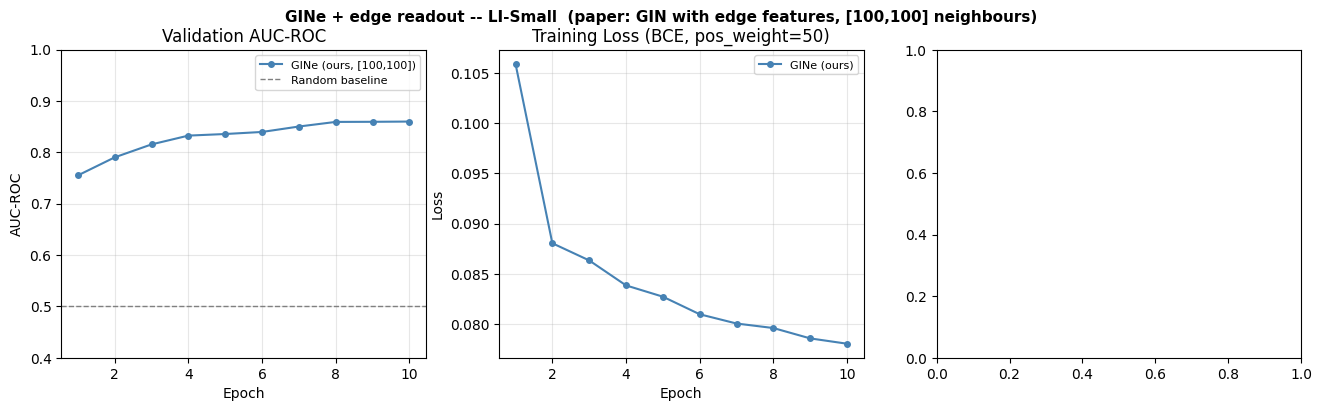

In [ ]:
# Training curves: shows how the model improved over 10 epochs
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    'GINe + edge readout -- LI-Small  (paper: GIN with edge features, [100,100] neighbours)',
    fontsize=11, fontweight='bold'
)

df_h = pd.DataFrame(gin_history)

# Plot 1: Validation AUC over epochs
axes[0].plot(df_h['epoch'], df_h['auc'],
             color='steelblue', marker='o', markersize=4, label='GINe (ours, [100,100])')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
axes[0].set_title('Validation AUC-ROC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_ylim(0.4, 1.0)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Training loss over epochs
axes[1].plot(df_h['epoch'], df_h['loss'],
             color='steelblue', marker='o', markersize=4, label='GINe (ours)')
axes[1].set_title('Training Loss (BCE, pos_weight=50)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall curve on test set
pre_curve, rec_curve, _ = precision_recall_curve(y_true, y_score)
ap         = average_precision_score(y_true, y_score)
laund_rate = y_true.mean()  # random classifier baseline = laundering rate

axes[2].plot(rec_curve, pre_curve,
             color='steelblue', linewidth=1.5, label=f'GINe (AP={ap:.3f})')
axes[2].axhline(laund_rate, color='gray', linestyle='--', linewidth=1,
                label=f'Random (AP={laund_rate:.4f})')

# Mark the optimal F1 threshold point on the PR curve
preds_f1 = (y_score >= gin_f1_thr).astype(int)
pre_f1   = precision_score(y_true, preds_f1, pos_label=1, zero_division=0)
rec_f1   = recall_score(y_true, preds_f1, pos_label=1, zero_division=0)
f1_val   = f1_score(y_true, preds_f1, pos_label=1, zero_division=0)
axes[2].scatter([rec_f1], [pre_f1], color='red', zorder=5, s=70,
                label=f'Optimal thr={gin_f1_thr:.3f}  F1={f1_val*100:.1f}%')

# Mark the threshold=0.5 point for paper comparison
preds_05 = (y_score >= 0.5).astype(int)
pre_05   = precision_score(y_true, preds_05, pos_label=1, zero_division=0)
rec_05   = recall_score(y_true, preds_05, pos_label=1, zero_division=0)
f1_05    = f1_score(y_true, preds_05, pos_label=1, zero_division=0)
axes[2].scatter([rec_05], [pre_05], color='orange', zorder=5, s=70,
                label=f'thr=0.5  F1={f1_05*100:.1f}%')

# Mark the paper's reported result for visual comparison
axes[2].scatter([0.1459], [0.0514], color='green', marker='*', zorder=5, s=150,
                label='Paper GINe+edge readout (thr=0.5, [100,100])')

axes[2].set_title('Precision-Recall Curve (test set)')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/gine_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Predictions for All Splits

In [15]:
@torch.no_grad()
def score_split(model, graph, split_name):
    """
    Score all evaluated edges in one graph split.

    Returns a DataFrame with one row per evaluated transaction containing:
    - split       : which split (train / val / test)
    - src_idx     : source account integer index (from edge_index[0])
    - dst_idx     : destination account integer index (from edge_index[1])
    - timestamp   : Unix timestamp of the transaction (from edge_time)
    - score       : predicted probability of laundering
    - label       : ground truth (0=legitimate, 1=laundering)

    The combination of (src_idx, dst_idx, timestamp) uniquely identifies
    most transactions and can be used to join back to LI-Small_Trans.csv
    via the account_to_idx mapping from Data_prepration.ipynb.

    Parameters
    ----------
    model      : trained GINe model
    graph      : PyG Data object
    split_name : 'train', 'val', or 'test'
    """
    model.eval()
    loader, seed_edge_attr = make_loader(graph, shuffle=False)

    all_probs      = []
    all_labels     = []
    all_input_ids  = []  # positions in seed pool, used to look up metadata

    pbar = tqdm(loader, desc=f'  Scoring {split_name}', leave=False)
    for batch in pbar:
        batch     = batch.to(device)
        seed_attr = seed_edge_attr[batch.input_id.cpu()].to(device)

        logits = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.edge_label_index,
            seed_attr,
        )
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(batch.edge_label.long().cpu().numpy())
        all_input_ids.append(batch.input_id.cpu().numpy())

    scores    = np.concatenate(all_probs)
    labels    = np.concatenate(all_labels)
    input_ids = np.concatenate(all_input_ids)  # positions into eval_mask subset

    # Recover graph-level metadata for eval edges only
    # input_ids index into the eval subset (graph.edge_index[:, eval_mask])
    eval_edge_index = graph.edge_index[:, graph.eval_mask]  # [2, n_eval]
    eval_edge_time  = graph.edge_time[graph.eval_mask]       # [n_eval]

    src_indices = eval_edge_index[0][input_ids].numpy()  # source account idx
    dst_indices = eval_edge_index[1][input_ids].numpy()  # destination account idx
    timestamps  = eval_edge_time[input_ids].numpy()       # Unix timestamp

    df = pd.DataFrame({
        'split'    : split_name,
        'src_idx'  : src_indices,
        'dst_idx'  : dst_indices,
        'timestamp': timestamps,
        'score'    : scores,
        'label'    : labels,
    })

    print(f'  {split_name}: {len(df):,} edges  |  '
          f'{(labels==1).sum():,} laundering  |  '
          f'score range [{scores.min():.4f}, {scores.max():.4f}]  |  '
          f'mean score laund={df[df.label==1].score.mean():.4f}  '
          f'legit={df[df.label==0].score.mean():.4f}')

    return df


# Score all three splits
print('Scoring all splits...\n')
df_train = score_split(gin_model, train_graph, 'train')
df_val   = score_split(gin_model, val_graph,   'val')
df_test  = score_split(gin_model, test_graph,  'test')

# # Add binary predictions at the three thresholds
# for df in [df_train, df_val, df_test]:
#     df['pred_thr05']      = (df['score'] >= 0.5).astype(int)
#     df['pred_thr_f1']     = (df['score'] >= gin_f1_thr).astype(int)
#     df['pred_thr_mcc']    = (df['score'] >= gin_mcc_thr).astype(int)

# Save individually and as one combined file
SAVE_DIR = 'Models/GINe_gfp/Predictions'
os.makedirs(SAVE_DIR, exist_ok=True)

df_train.to_csv(f'{SAVE_DIR}/gine_predictions_train_gfp_epocs_20_21_05_26.csv', index=False)
df_val.to_csv(  f'{SAVE_DIR}/gine_predictions_val_gfp_epocs_20_21_05_26.csv',   index=False)
df_test.to_csv( f'{SAVE_DIR}/gine_predictions_test_gfp_epocs_20_21_05_26.csv',  index=False)

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all.to_csv(f'{SAVE_DIR}/gine_predictions_all_gfp_epocs_20_21_05_26.csv', index=False)

print(f'\nSaved to {SAVE_DIR}/')
print(f'  gine_predictions_train_gfp_21_05_26.csv : {len(df_train):,} rows')
print(f'  gine_predictions_val_gfp_21_05_26.csv   : {len(df_val):,} rows')
print(f'  gine_predictions_test_gfp_21_05_26.csv  : {len(df_test):,} rows')
print(f'  gine_predictions_all_gfp_21_05_26.csv   : {len(df_all):,} rows')
print(f'\nSample rows from test set:')
print(df_test.head(5).to_string(index=False))

Scoring all splits...



  train: 4,154,429 edges  |  1,813 laundering  |  score range [0.0000, 0.9627]  |  mean score laund=0.3040  legit=0.0024


  val: 1,384,810 edges  |  827 laundering  |  score range [0.0000, 0.9649]  |  mean score laund=0.2400  legit=0.0026


  test: 1,384,810 edges  |  925 laundering  |  score range [0.0000, 0.9578]  |  mean score laund=0.2421  legit=0.0025

Saved to Models/GINe_gfp/Predictions/
  gine_predictions_train_gfp_21_05_26.csv : 4,154,429 rows
  gine_predictions_val_gfp_21_05_26.csv   : 1,384,810 rows
  gine_predictions_test_gfp_21_05_26.csv  : 1,384,810 rows
  gine_predictions_all_gfp_21_05_26.csv   : 6,924,049 rows

Sample rows from test set:
split  src_idx  dst_idx  timestamp    score  label
 test   635035   161142 1662653160 0.000018      0
 test   470380   296063 1662653160 0.000015      0
 test   298128   709528 1662653160 0.000028      0
 test   281432   548388 1662653160 0.000015      0
 test   692348   330214 1662653160 0.000030      0
